In [161]:
# ============================================================
# 1. Physics Defined & Imports
# ============================================================

"""
Physics-Informed Neural Network: Burgers' Equation

Governing Equation:       ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
                          x ∈ [-1,1], t ∈ [0,1]

Boundary Conditions:      u(-1,t) = 0
                          u(1,t) = 0

Initial Condition:        u(x,0) = -sin(πx)

Viscosity:                ν = 0.01/π
"""

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [162]:
# ============================================================
# 2. SETUP
# ============================================================
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")



# Exact solution for validation
# Load reference solution from data file
# Download from: https://github.com/lululxvi/deepxde/blob/master/examples/dataset/Burgers.npz
data_ref = np.load("Burgers.npz")
x_ref = data_ref["x"].flatten()[:, None]  # Spatial coordinates
t_ref = data_ref["t"].flatten()[:, None]  # Time coordinates
u_ref = data_ref["usol"].T.flatten()[:, None]  # Reference solution

Set the default float type to float64
Backend: pytorch


In [163]:
print(x_ref.shape)
print(t_ref.shape)
print(u_ref.shape)

(256, 1)
(100, 1)
(25600, 1)


In [164]:
import pandas as pd

# Create space–time grid
X, T = np.meshgrid(x_ref, t_ref, indexing="ij")

# Create DataFrame
df = pd.DataFrame({
    "x": X.flatten(),
    "t": T.flatten(),
    "u": u_ref.flatten()
})

# Display df
print(df)

         x     t             u
0     -1.0  0.00  1.224647e-16
1     -1.0  0.01  2.463745e-02
2     -1.0  0.02  4.925994e-02
3     -1.0  0.03  7.385253e-02
4     -1.0  0.04  9.840028e-02
...    ...   ...           ...
25595  1.0  0.95 -2.393421e-02
25596  1.0  0.96 -1.795085e-02
25597  1.0  0.97 -1.196732e-02
25598  1.0  0.98 -5.983687e-03
25599  1.0  0.99  1.123888e-16

[25600 rows x 3 columns]


In [165]:
# ============================================================
# 3. DEFINE PROBLEM
# ============================================================

# Domain geometry
# Spatial domain: x ∈ [-1, 1]
geom = dde.geometry.Interval(-1, 1)

# Temporal domain: t ∈ [0, 1]
timedomain = dde.geometry.TimeDomain(0, 1.0)

# Combined space-time domain
geomtime = dde.geometry.GeometryXTime(geom, timedomain)





# PDE: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
def pde(x, y):
    # x[:, 0] = spatial coordinate (x)
    # x[:, 1] = temporal coordinate (t)
    
    # First derivatives
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)  # ∂u/∂t
    dy_x = dde.grad.jacobian(y, x, i=0, j=0)  # ∂u/∂x
    
    # Second derivative
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)  # ∂²u/∂x²
    
    # Viscosity coefficient
    nu = 0.01 / np.pi

    # Burgers' equation residual
    return dy_t + y * dy_x - nu * dy_xx





# Boundary condition: u(-1,t) = u(1,t) = 0
def boundary_condition(x, on_boundary):
    # x[0] is spatial coordinate
    return on_boundary and (np.isclose(x[0], -1) or np.isclose(x[0], 1))

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, boundary_condition)

# Initial condition: u(x,0) = -sin(πx)
ic = dde.icbc.IC(
    geomtime,
    lambda x: -np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

In [166]:
# ============================================================
# 4. GENERATE DATA
# ============================================================
# # 1. Load experimental data (If actual Experimental or FEA Data is Available)
    # pip install pandas
    # pip install numpy
    # pip install scikit-learn

    # import pandas as pd
    # import numpy as np
    # from sklearn.model_selection import train_test_split

    # # Load your experimental/FEA data
    # df = pd.read_excel("experiment_data.xlsx")

    # # Extract full dataset
    # X = df['x'].values.reshape(-1, 1)
    # Y = df['y'].values.reshape(-1, 1)

    # # RANDOM 85% Train — 15% Test
    # X_train, X_test, Y_train, Y_test = train_test_split(
    #     X, Y, test_size=0.15, shuffle=True, random_state=42
    # )

    # # Observation data for PINN
    # observe_x = X_train
    # observe_y = Y_train





# Combine all data
# Create PDE data WITHOUT observation points (pure physics-based)
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=15000,      # Interior collocation points
    num_boundary=300,      # Spatial boundary points
    num_initial=300,      # Initial condition points
    num_test=1000        # Test points for evaluation
)

In [167]:
# ============================================================
# 5. BUILD NEURAL NETWORK
# ============================================================

# Architecture: 2 inputs (x,t) → 3 hidden layers → 1 output (u)
net = dde.nn.FNN(layer_sizes=[2, 32, 16, 8, 1],  # Dynamic and efficient!
                 activation="tanh",  # Smooth and physics-friendly!
                 kernel_initializer="Glorot uniform",  # Stable init!
                )

In [168]:
# ============================================================
# 6. CREATE MODEL
# ============================================================

model = dde.Model(data, net)

In [169]:
# ============================================================
# 7. SET LOSS WEIGHTS (λ parameters)
# ============================================================

"""
CRITICAL: DeepXDE loss weight configuration for Burgers' Equation

Loss components:
  - losses[0]: PDE residual loss (L_PDE) → Burgers' equation: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
  - losses[1]: Boundary condition loss (L_BC) → u(-1,t) = u(1,t) = 0
  - losses[2]: Initial condition loss (L_IC) → u(x,0) = -sin(πx)

Total Loss = λ_PDE*L_PDE + λ_BC*L_BC + λ_IC*L_IC

Note: Unlike the Euler beam problem, Burgers' equation is time-dependent with:
  - Spatial domain: x ∈ [-1, 1]
  - Temporal domain: t ∈ [0, 1]
  - No measurement data (pure physics-informed approach)
"""

# Define loss weights (tune these for your problem)
loss_weights = [
    20.0,    # λ_PDE: Burgers' equation residual weight
    1.0,    # λ_BC: Dirichlet boundary conditions weight (both boundaries)
    5.0     # λ_IC: Initial condition weight
]

print("\n" + "="*70)
print("📊 LOSS WEIGHT CONFIGURATION - BURGERS' EQUATION")
print("="*70)
print(f"λ_PDE (Burgers' Equation):           {loss_weights[0]}")
print(f"λ_BC  (u(-1,t) = u(1,t) = 0):        {loss_weights[1]}")
print(f"λ_IC  (u(x,0) = -sin(πx)):           {loss_weights[2]}")
print("="*70)
print("\n📌 Problem Configuration:")
print(f"   • Governing PDE: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0")
print(f"   • Viscosity: ν = 0.01/π ≈ {0.01/np.pi:.6f}")
print(f"   • Domain: x ∈ [-1, 1], t ∈ [0, 1]")
print(f"   • Boundary Conditions: 2 Dirichlet (spatial boundaries)")
print(f"   • Initial Condition: 1 (at t=0)")
print("="*70)


📊 LOSS WEIGHT CONFIGURATION - BURGERS' EQUATION
λ_PDE (Burgers' Equation):           20.0
λ_BC  (u(-1,t) = u(1,t) = 0):        1.0
λ_IC  (u(x,0) = -sin(πx)):           5.0

📌 Problem Configuration:
   • Governing PDE: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
   • Viscosity: ν = 0.01/π ≈ 0.003183
   • Domain: x ∈ [-1, 1], t ∈ [0, 1]
   • Boundary Conditions: 2 Dirichlet (spatial boundaries)
   • Initial Condition: 1 (at t=0)


In [170]:
# %%
# ============================================================
# 8. TRAIN MODEL (Two-Stage Optimization)
# ============================================================

print("\n" + "="*70)
print("🚀 TRAINING PHYSICS-INFORMED NEURAL NETWORK")
print("="*70)

# Stage 1: Adam Optimizer
print("\n📍 Stage 1: Adam Optimizer")
print("-"*70)
model.compile(
    "adam",
    lr=0.001,
    loss_weights=loss_weights,
    decay=("inverse time", 3000, 0.6)
)
losshistory, train_state = model.train(iterations=12000, display_every=1000)

# Stage 2: L-BFGS Optimizer
print("\n📍 Stage 2: L-BFGS Optimizer (Fine-tuning)")
print("-"*70)
model.compile(
    "L-BFGS",
    loss_weights=loss_weights,    
)
losshistory, train_state = model.train(display_every=200)

print("\n✅ Training Complete!")
print("="*70)


🚀 TRAINING PHYSICS-INFORMED NEURAL NETWORK

📍 Stage 1: Adam Optimizer
----------------------------------------------------------------------
Compiling model...
'compile' took 0.000185 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [6.65e-01, 2.12e-01, 1.31e+00]    [6.39e-01, 2.12e-01, 1.31e+00]    []  
1000      [1.35e-01, 1.34e-02, 5.60e-01]    [1.49e-01, 1.34e-02, 5.60e-01]    []  
2000      [1.02e-01, 4.06e-03, 4.82e-01]    [1.15e-01, 4.06e-03, 4.82e-01]    []  
3000      [8.92e-02, 2.33e-03, 4.45e-01]    [1.41e-01, 2.33e-03, 4.45e-01]    []  
4000      [7.89e-02, 1.78e-03, 3.70e-01]    [7.43e-02, 1.78e-03, 3.70e-01]    []  
5000      [7.28e-02, 2.00e-03, 2.05e-01]    [1.21e-01, 2.00e-03, 2.05e-01]    []  
6000      [5.60e-02, 1.21e-03, 8.16e-02]    [5.06e-02, 1.21e-03, 8.16e-02]    []  
7000      [4.38e-02, 6.66e-04, 5.18e-02]    [4.53e-02, 6.66e-04, 5.18e-02]    []  
8000      [3.53e-02, 4.81e-04, 3.91e-02

In [ ]:
# ============================================================
# 9. EVALUATE RESULTS
# ============================================================
# Space-time mesh
X, T = np.meshgrid(x_ref, t_ref)
X_test = np.hstack((
    X.flatten()[:, None],
    T.flatten()[:, None]
))
# Predictions
y_pred = model.predict(X_test)
# Exact solution
y_test = u_ref.flatten()[:, None]
# Error metrics
absolute_error = np.abs(y_test - y_pred)
relative_error = absolute_error / (np.abs(y_test) + 1e-10)
l2_error = np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)
print("\n" + "="*70)
print("📊 PERFORMANCE METRICS")
print("="*70)
print(f"L2 Relative Error:      {l2_error:.6e}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6e}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6e}")



# Boundary & Initial Condition Checks

print("\n📍 BOUNDARY CONDITION CHECK: u(-1,t) = u(1,t) = 0")
print("-"*70)
t_check = [0.0, 0.5, 1.0]
for t_val in t_check:
    u_left = model.predict(np.array([[-1.0, t_val]]))[0, 0]
    u_right = model.predict(np.array([[1.0, t_val]]))[0, 0]
    print(f"t={t_val:.1f}: u(-1,t)={u_left:.6f}, u(1,t)={u_right:.6f}")



print("\n📍 INITIAL CONDITION CHECK: u(x,0) = -sin(πx)")
print("-"*70)
x_check = np.linspace(-1, 1, 5)
for x_val in x_check:
    u_pred = model.predict(np.array([[x_val, 0.0]]))[0, 0]
    u_exact = -np.sin(np.pi * x_val)
    error = abs(u_pred - u_exact)
    print(f"x={x_val:+.2f}: u={u_pred:.6f} | exact={u_exact:.6f} | error={error:.6f}")
print("="*70)


📊 PERFORMANCE METRICS
L2 Relative Error:      4.004214e-03
Max Absolute Error:     2.592877e-02
Mean Absolute Error:    9.964748e-04

📍 BOUNDARY CONDITION CHECK: u(-1,t) = u(1,t) = 0
----------------------------------------------------------------------
t=0.0: u(-1,t)=-0.001050, u(1,t)=-0.000661
t=0.5: u(-1,t)=0.000379, u(1,t)=-0.000361
t=1.0: u(-1,t)=-0.000284, u(1,t)=-0.000648

📍 INITIAL CONDITION CHECK: u(x,0) = -sin(πx)
----------------------------------------------------------------------
x=-1.00: u=-0.001050 | exact=0.000000 | error=0.001050
x=-0.50: u=1.002241 | exact=1.000000 | error=0.002241
x=+0.00: u=0.001717 | exact=-0.000000 | error=0.001717
x=+0.50: u=-1.001669 | exact=-1.000000 | error=0.001669
x=+1.00: u=-0.000661 | exact=-0.000000 | error=0.000661


In [172]:
# ==================================
# 10. EXTRACT TRUE INDIVIDUAL LOSSES
# ==================================
# DeepXDE already computes the exact losses used during training
final_train_losses = model.losshistory.loss_train[-1]   # [L_PDE, L_BC, L_IC]

L_pde, L_bc, L_ic = final_train_losses

print("\n" + "="*70)
print("📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)")
print("="*70)
print(f"L_PDE (Burgers' equation)     : {L_pde:.6e}")
print(f"L_BC  (u(-1,t)=u(1,t)=0)      : {L_bc:.6e}")
print(f"L_IC  (u(x,0)=-sin(πx))       : {L_ic:.6e}")



print("\n📉 WEIGHTED CONTRIBUTIONS")
print("="*70)
weighted = [w * l for w, l in zip(loss_weights, final_train_losses)]
print(f"λ_PDE × L_PDE                 : {weighted[0]:.6e}")
print(f"λ_BC  × L_BC                  : {weighted[1]:.6e}")
print(f"λ_IC  × L_IC                  : {weighted[2]:.6e}")
print(f"\nTotal Weighted Loss           : {sum(weighted):.6e}")
print("="*70)


📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)
L_PDE (Burgers' equation)     : 3.386209e-04
L_BC  (u(-1,t)=u(1,t)=0)      : 2.403484e-07
L_IC  (u(x,0)=-sin(πx))       : 4.874145e-05

📉 WEIGHTED CONTRIBUTIONS
λ_PDE × L_PDE                 : 6.772419e-03
λ_BC  × L_BC                  : 2.403484e-07
λ_IC  × L_IC                  : 2.437073e-04

Total Weighted Loss           : 7.016367e-03


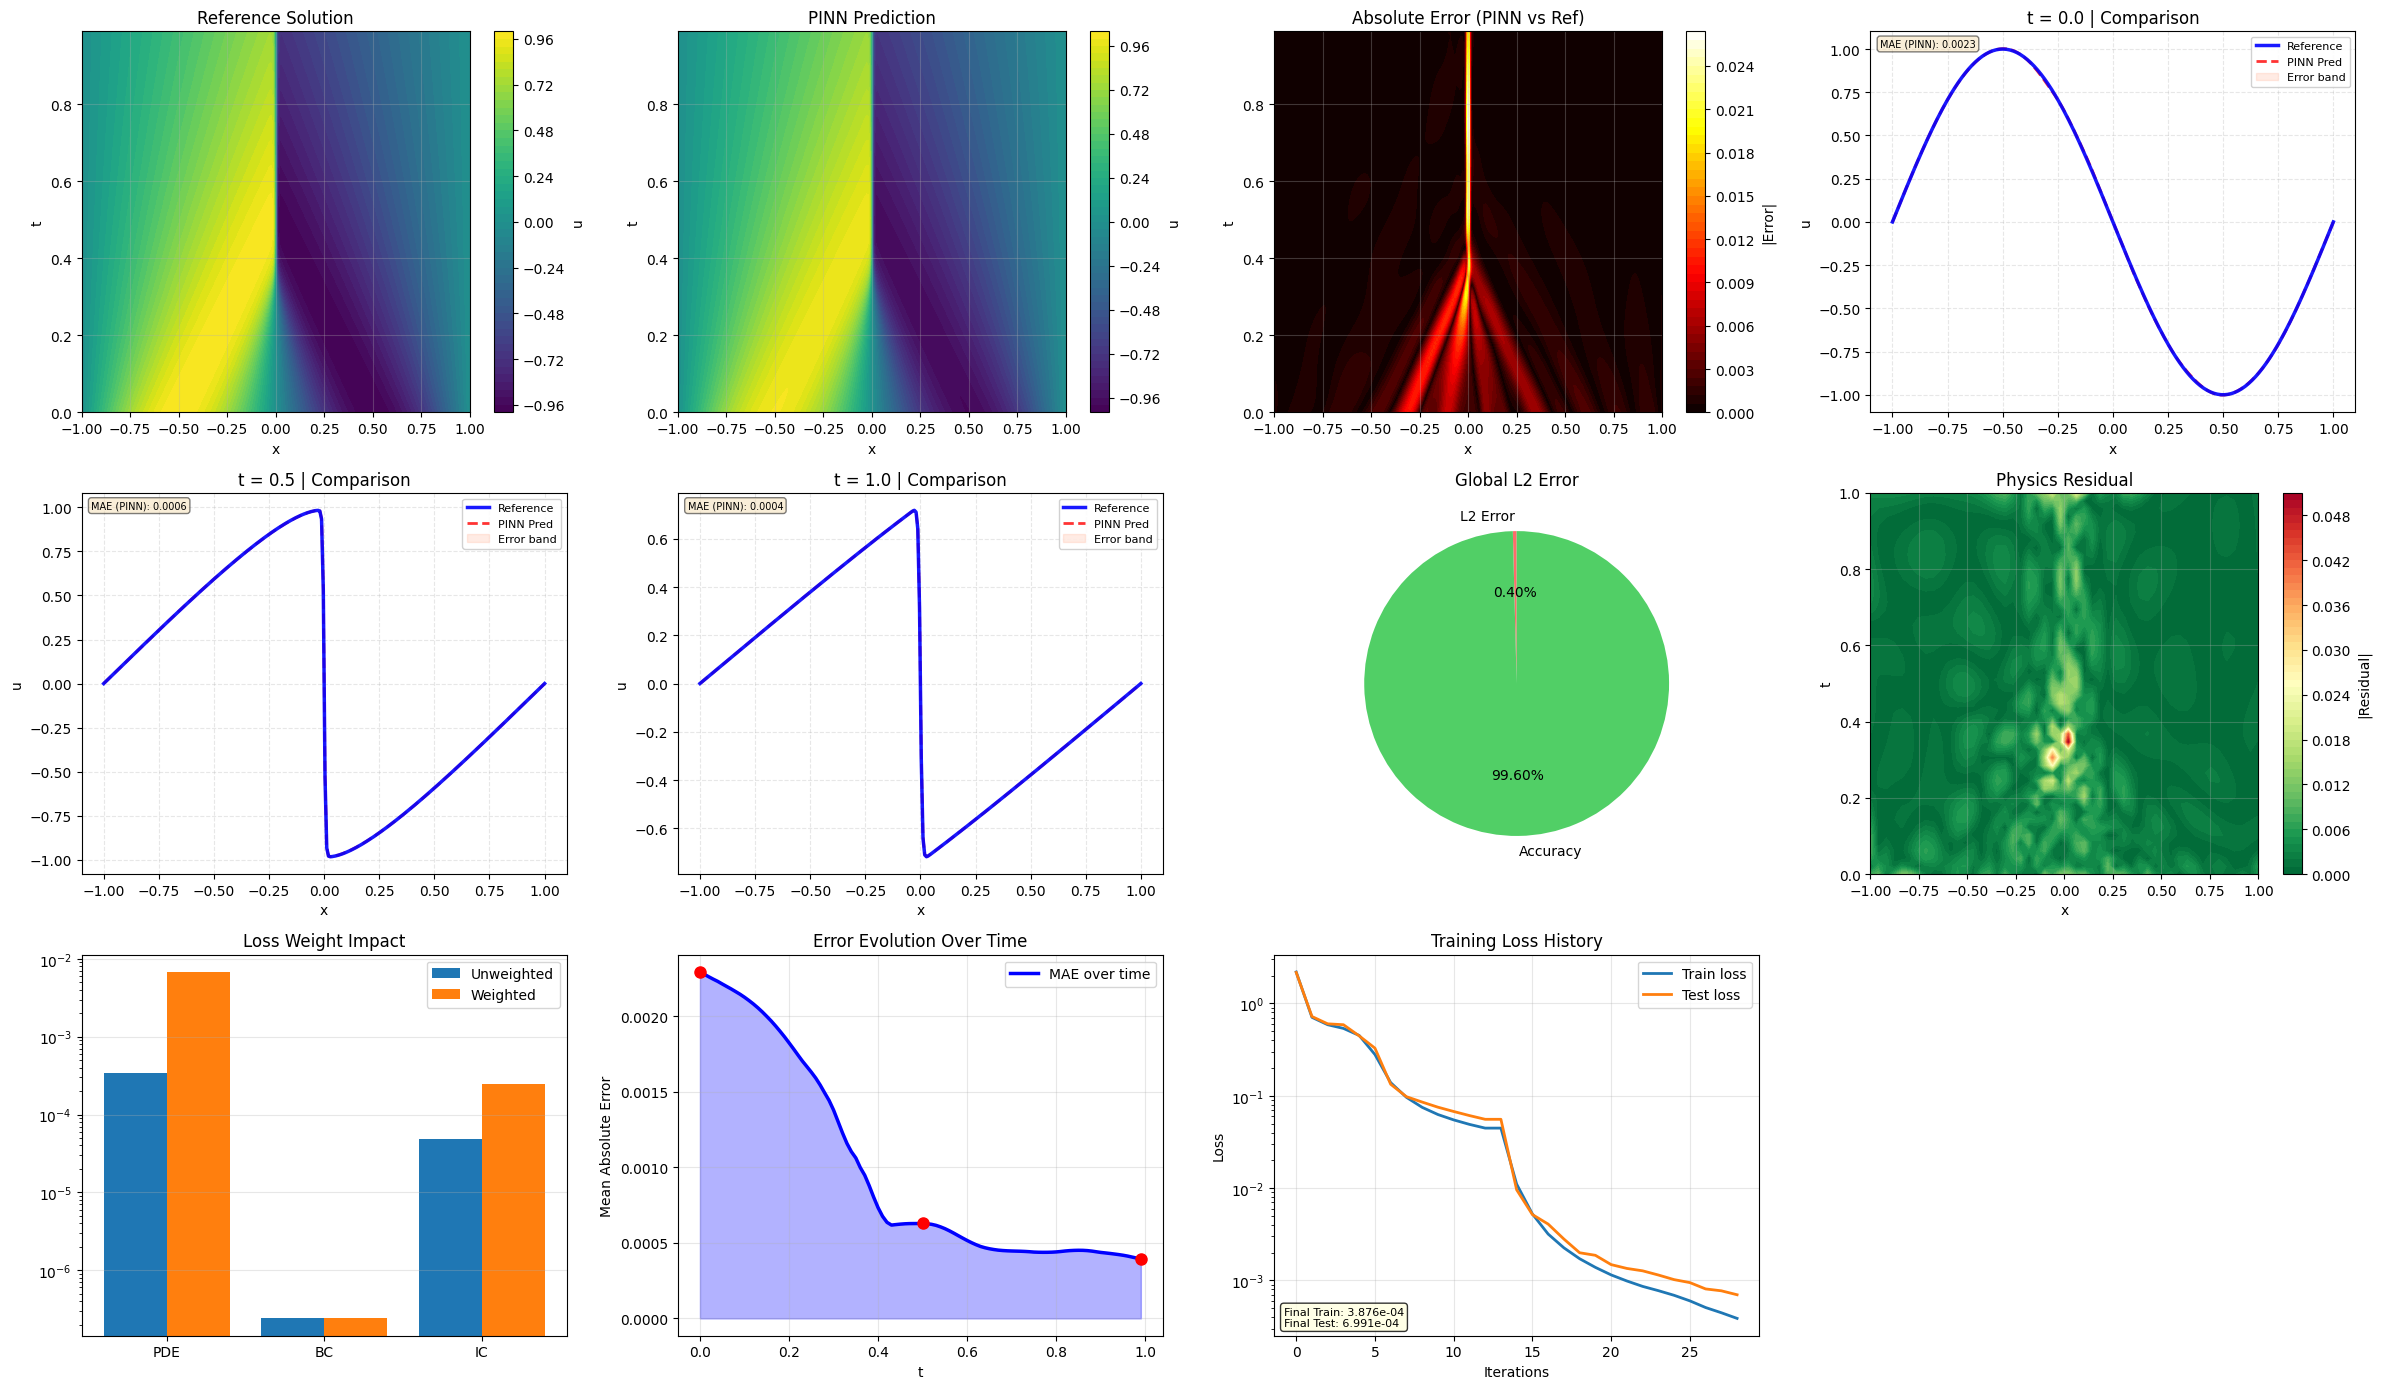


📊 COMPARISON STATISTICS

Metric                                             Value
----------------------------------------------------------------------
Mean Absolute Error (PINN vs Ref)           9.964748e-04
L2 Relative Error (PINN)                    4.004214e-03

📍 ERROR STATISTICS AT KEY TIMES

t = 0.0:
  Mean Absolute Error: 2.292621e-03
  Max Absolute Error:  1.023194e-02

t = 0.5:
  Mean Absolute Error: 6.280923e-04
  Max Absolute Error:  2.210300e-02

t = 1.0:
  Mean Absolute Error: 3.940262e-04
  Max Absolute Error:  1.869034e-02


In [173]:
# ============================================================
# 11. VISUALIZATION (STREAMLINED) - OPTIMIZED
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import deepxde as dde
# ------------------------------------------------------------
# Prepare data (DeepXDE → Matplotlib safe)
# ------------------------------------------------------------
Nx = len(x_ref)
Nt = len(t_ref)
x_plot = x_ref.flatten()
t_plot = t_ref.flatten()
X, T = np.meshgrid(x_plot, t_plot)
u_ref_mesh  = u_ref.reshape(Nt, Nx)
u_pred_mesh = y_pred.reshape(Nt, Nx)
error_mesh  = np.abs(u_ref_mesh - u_pred_mesh)
# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 14))
# ------------------------------------------------------------
# (1) Reference Solution
# ------------------------------------------------------------
ax1 = plt.subplot(3, 4, 1)
c1 = ax1.contourf(X, T, u_ref_mesh, 50, cmap="viridis")
plt.colorbar(c1, ax=ax1, label="u")
ax1.set(title="Reference Solution", xlabel="x", ylabel="t")
ax1.grid(alpha=0.3)
# ------------------------------------------------------------
# (2) PINN Prediction
# ------------------------------------------------------------
ax2 = plt.subplot(3, 4, 2)
c2 = ax2.contourf(X, T, u_pred_mesh, 50, cmap="viridis")
plt.colorbar(c2, ax=ax2, label="u")
ax2.set(title="PINN Prediction", xlabel="x", ylabel="t")
ax2.grid(alpha=0.3)
# ------------------------------------------------------------
# (3) Absolute Error (PINN vs Reference)
# ------------------------------------------------------------
ax3 = plt.subplot(3, 4, 3)
c3 = ax3.contourf(X, T, error_mesh, 50, cmap="hot")
plt.colorbar(c3, ax=ax3, label="|Error|")
ax3.set(title="Absolute Error (PINN vs Ref)", xlabel="x", ylabel="t")
ax3.grid(alpha=0.3)
# ------------------------------------------------------------
# (4-6) TWO-CURVE DETAILED COMPARISON at t=0, 0.5, 1.0
# ------------------------------------------------------------
for i, t_val in enumerate([0.0, 0.5, 1.0]):
    ax = plt.subplot(3, 4, 4 + i)
    idx = np.argmin(np.abs(t_plot - t_val))
    # 1. Reference Solution (blue solid)
    ax.plot(x_plot, u_ref_mesh[idx], 'b-', lw=2.5,
            label="Reference", alpha=0.9, zorder=3)
    
    # 2. PINN Prediction (red dashed)
    ax.plot(x_plot, u_pred_mesh[idx], 'r--', lw=2,
            label="PINN Pred", alpha=0.8, zorder=2)
    
    # Error band between reference and PINN
    ax.fill_between(x_plot, u_ref_mesh[idx], u_pred_mesh[idx],
                    alpha=0.15, color='coral', label='Error band')
    ax.set(title=f"t = {t_val:.1f} | Comparison",
           xlabel="x", ylabel="u")
    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')
    
    # Add error statistics as text
    error_mean = np.mean(np.abs(u_ref_mesh[idx] - u_pred_mesh[idx]))
    ax.text(0.02, 0.98, f'MAE (PINN): {error_mean:.4f}',
            transform=ax.transAxes, fontsize=7,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.5))
# ------------------------------------------------------------
# (7) Global L2 Error
# ------------------------------------------------------------
ax7 = plt.subplot(3, 4, 7)
ax7.pie(
    [100*l2_error, 100*(1-l2_error)],
    labels=["L2 Error", "Accuracy"],
    autopct="%.2f%%",
    startangle=90,
    colors=["#ff6b6b", "#51cf66"]
)
ax7.set_title("Global L2 Error")
# ------------------------------------------------------------
# (8) Physics Residual
# ------------------------------------------------------------
ax8 = plt.subplot(3, 4, 8)
x_s = np.linspace(-1, 1, 50)
t_s = np.linspace(0, 1, 50)
Xs, Ts = np.meshgrid(x_s, t_s)
XT = np.hstack((Xs.flatten()[:, None], Ts.flatten()[:, None]))
res = model.predict(XT, operator=pde).reshape(50, 50)
c8 = ax8.contourf(Xs, Ts, np.abs(res), 50, cmap="RdYlGn_r")
plt.colorbar(c8, ax=ax8, label="|Residual|")
ax8.set(title="Physics Residual", xlabel="x", ylabel="t")
ax8.grid(alpha=0.3)
# ------------------------------------------------------------
# (9) Loss Weight Impact
# ------------------------------------------------------------
ax9 = plt.subplot(3, 4, 9)
losses = np.array(model.losshistory.loss_train[-1])
weighted = np.array(loss_weights) * losses
labels = ["PDE", "BC", "IC"]
xpos = np.arange(len(labels))
ax9.bar(xpos - 0.2, losses, 0.4, label="Unweighted")
ax9.bar(xpos + 0.2, weighted, 0.4, label="Weighted")
ax9.set_yscale("log")
ax9.set_xticks(xpos)
ax9.set_xticklabels(labels)
ax9.set_title("Loss Weight Impact")
ax9.legend()
ax9.grid(alpha=0.3, axis="y")
# ------------------------------------------------------------
# (10) Mean Absolute Error vs Time
# ------------------------------------------------------------
ax10 = plt.subplot(3, 4, 10)
mae_t = np.mean(error_mesh, axis=1)
ax10.plot(t_plot, mae_t, 'b-', lw=2.5, label='MAE over time')
ax10.fill_between(t_plot, 0, mae_t, alpha=0.3, color='blue')
ax10.set(title="Error Evolution Over Time",
         xlabel="t", ylabel="Mean Absolute Error")
ax10.grid(alpha=0.3)
# Mark the three comparison times
for t_val in [0.0, 0.5, 1.0]:
    idx = np.argmin(np.abs(t_plot - t_val))
    ax10.plot(t_plot[idx], mae_t[idx], 'ro', markersize=8)
ax10.legend()
# ------------------------------------------------------------
# (11) Training Loss History
# ------------------------------------------------------------
ax11 = plt.subplot(3, 4, 11)
train_loss = np.sum(np.array(losshistory.loss_train), axis=1)
test_loss  = np.sum(np.array(losshistory.loss_test), axis=1)
ax11.plot(train_loss, lw=2, label="Train loss", color='#1f77b4')
ax11.plot(test_loss, lw=2, label="Test loss", color='#ff7f0e')
ax11.set_yscale("log")
ax11.set_title("Training Loss History")
ax11.set_xlabel("Iterations")
ax11.set_ylabel("Loss")
ax11.legend(loc='upper right')
ax11.grid(alpha=0.3)
# Add final loss values as text
final_train = train_loss[-1]
final_test = test_loss[-1]
ax11.text(0.02, 0.02, f'Final Train: {final_train:.3e}\nFinal Test: {final_test:.3e}',
          transform=ax11.transAxes, fontsize=8,
          verticalalignment='bottom', bbox=dict(boxstyle='round',
          facecolor='lightyellow', alpha=0.8))
# ------------------------------------------------------------
# Finalize
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig("pinn_burgers_results.png", dpi=300, bbox_inches='tight')
plt.show()
# ------------------------------------------------------------
# Print Error Statistics
# ------------------------------------------------------------
print("\n" + "="*70)
print("📊 COMPARISON STATISTICS")
print("="*70)
print(f"\n{'Metric':<40} {'Value':>15}")
print("-"*70)
# Errors w.r.t Reference
mae_pinn = np.mean(np.abs(u_ref_mesh - u_pred_mesh))
print(f"{'Mean Absolute Error (PINN vs Ref)':<40} {mae_pinn:>15.6e}")
# L2 errors
l2_pinn = np.linalg.norm(u_ref_mesh - u_pred_mesh) / np.linalg.norm(u_ref_mesh)
print(f"{'L2 Relative Error (PINN)':<40} {l2_pinn:>15.6e}")
# Statistics at each comparison time
print("\n" + "="*70)
print("📍 ERROR STATISTICS AT KEY TIMES")
print("="*70)
for t_val in [0.0, 0.5, 1.0]:
    idx = np.argmin(np.abs(t_plot - t_val))
    mae = np.mean(np.abs(u_ref_mesh[idx] - u_pred_mesh[idx]))
    max_err = np.max(np.abs(u_ref_mesh[idx] - u_pred_mesh[idx]))
    print(f"\nt = {t_val:.1f}:")
    print(f"  Mean Absolute Error: {mae:.6e}")
    print(f"  Max Absolute Error:  {max_err:.6e}")
print("="*70)

In [174]:
# %%
# ============================================================
# 12. FINAL SUMMARY
# ============================================================

# Helper for perfect alignment
def fmt(label, value, width_label=45, width_value=12):
    return f"{label:<{width_label}} : {value:>{width_value}}"


print("\n" + "=" * 70)
print("📋 FINAL SUMMARY".center(70))
print("=" * 70)



# ------------------------------------------------------------
# Training Points Summary
# ------------------------------------------------------------
print("\n" + "═" * 70)
print("TRAINING POINTS CONFIGURATION".center(70))
print("═" * 70)

print(fmt("Physics collocation points (num_domain)", data.num_domain))
print(fmt("Boundary points (num_boundary)", data.num_boundary))
print(fmt("Initial condition points (num_initial)", data.num_initial))
print(fmt("Total training points used", data.train_x_all.shape[0]))
print("-" * 70)
print(fmt("Test/evaluation points (num_test)", data.num_test))
print("═" * 70)



# ------------------------------------------------------------
# Neural Network Architecture
# ------------------------------------------------------------
print("\nNEURAL NETWORK ARCHITECTURE")
print("-" * 70)
print(net)
print("-" * 70)



# ------------------------------------------------------------
# Best Model Performance Summary (Lowest Test Loss)
# ------------------------------------------------------------
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test  = model.losshistory.loss_test[best_step]

total_train = sum(best_train)
total_test  = sum(best_test)

print("\n" + "═" * 70)
print("BEST MODEL PERFORMANCE (Lowest Total Test Loss)".center(70))
print("═" * 70)

print(fmt("Best training step/iteration", best_step))
print("-" * 70)
print(fmt("Total weighted training loss", f"{total_train:.6e}"))
print("-" * 70)

print(fmt("Train → PDE loss (Burgers' eq)",     f"{best_train[0]:.6e}"))
print(fmt("Train → BC loss (u(-1,t)=u(1,t)=0)", f"{best_train[1]:.6e}"))
print(fmt("Train → IC loss (u(x,0)=-sin(πx))",  f"{best_train[2]:.6e}"))

print("-" * 70)

print(fmt("Total weighted test loss", f"{total_test:.6e}"))
print("-" * 70)
print(fmt("Test → PDE loss (Burgers' eq)",     f"{best_test[0]:.6e}"))
print(fmt("Test → BC loss (u(-1,t)=u(1,t)=0)", f"{best_test[1]:.6e}"))
print(fmt("Test → IC loss (u(x,0)=-sin(πx))",  f"{best_test[2]:.6e}"))
print("═" * 70)



# ------------------------------------------------------------
# Final Individual Losses
# ------------------------------------------------------------
losses = model.losshistory.loss_train[-1]

print("\n" + "═" * 70)
print("FINAL TRAINING LOSSES (Last Iteration)".center(70))
print("═" * 70)

print(f"{'Component':<25} {'Unweighted':>15} {'Weighted (λ×L)':>20} {'λ':>8}")
print("-" * 70)

components = ['PDE (Burgers)', 'BC (Boundaries)', 'IC (Initial)']

for i, comp in enumerate(components):
    L = losses[i]
    w = loss_weights[i]
    print(f"{comp:<25} {L:>15.6e} {w*L:>20.6e} {w:>8}")

print("-" * 70)
total_loss = sum(w * l for w, l in zip(loss_weights, losses))
print(f"{'TOTAL WEIGHTED LOSS':<25}{total_loss:>20.6e}")
print("═" * 70)



# ------------------------------------------------------------
# Metrics Summary
# ------------------------------------------------------------
print("\n📊 METRICS")
print("-" * 70)
print(f"{'Metric':<30} {'Value':>15} {'Target'}")
print("-" * 70)

print(f"{'L2 Relative Error':<30} {l2_error:>15.6f} < 0.05 (excellent)")
print(f"{'Mean Absolute Error':<30} {np.mean(absolute_error):>15.6f} < 0.10")
print(f"{'Max Absolute Error':<30} {np.max(absolute_error):>15.6f} < 0.20")
print(f"{'Mean Relative Error':<30} {np.mean(relative_error):>15.6f} < 0.20")

print("\n📍 BOUNDARY & INITIAL CONDITIONS")
print("-" * 70)

# Check boundary conditions at different times
print("Boundary Conditions: u(-1,t) = u(1,t) = 0")
t_check = [0.0, 0.5, 1.0]
for t_val in t_check:
    u_left = model.predict(np.array([[-1.0, t_val]]))[0, 0]
    u_right = model.predict(np.array([[1.0, t_val]]))[0, 0]
    print(f"  t={t_val:.1f}: u(-1,t)={u_left:>10.6f}, u(1,t)={u_right:>10.6f}")

print("\nInitial Condition: u(x,0) = -sin(πx)")
x_check = [-1.0, -0.5, 0.0, 0.5, 1.0]
ic_errors = []
for x_val in x_check:
    u_pred = model.predict(np.array([[x_val, 0.0]]))[0, 0]
    u_exact = -np.sin(np.pi * x_val)
    error = abs(u_pred - u_exact)
    ic_errors.append(error)
    print(f"  x={x_val:+.1f}: u_pred={u_pred:>10.6f}, u_exact={u_exact:>10.6f}, error={error:.6f}")

print(f"\nMean IC Error: {np.mean(ic_errors):.6f}")

# PDE residual check
print("\n📍 PHYSICS RESIDUAL CHECK")
print("-" * 70)
x_sample = np.linspace(-1, 1, 50)
t_sample = np.linspace(0, 1, 50)
X_sample, T_sample = np.meshgrid(x_sample, t_sample)
XT_sample = np.hstack((X_sample.flatten()[:, None], T_sample.flatten()[:, None]))

pde_residual = model.predict(XT_sample, operator=pde)
pde_res_mean = np.mean(np.abs(pde_residual))
pde_res_max = np.max(np.abs(pde_residual))

print(f"{'PDE Residual (mean abs)':<30} {pde_res_mean:>15.6f} < 0.01 (excellent)")
print(f"{'PDE Residual (max abs)':<30} {pde_res_max:>15.6f} < 0.10")

print("=" * 70)


                           📋 FINAL SUMMARY                            

══════════════════════════════════════════════════════════════════════
                    TRAINING POINTS CONFIGURATION                     
══════════════════════════════════════════════════════════════════════
Physics collocation points (num_domain)       :        15000
Boundary points (num_boundary)                :          300
Initial condition points (num_initial)        :          300
Total training points used                    :        15600
----------------------------------------------------------------------
Test/evaluation points (num_test)             :         1000
══════════════════════════════════════════════════════════════════════

NEURAL NETWORK ARCHITECTURE
----------------------------------------------------------------------
FNN(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): Linear(in

In [175]:
# ============================================================
# 13. SAVE MODEL
# ============================================================
model.save("pinn_burgers_model")
print("\n💾 Model saved to 'pinn_burgers_model/'")
# Save configuration
config = {
    'problem': 'Burgers Equation',
    'equation': '∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0',
    'domain': {
        'spatial': '[-1, 1]',
        'temporal': '[0, 1]'
    },
    'boundary_conditions': {
        'left': 'u(-1,t) = 0',
        'right': 'u(1,t) = 0'
    },
    'initial_condition': 'u(x,0) = -sin(πx)',
    'viscosity': 0.01 / np.pi,
    'loss_weights': {
        'PDE': loss_weights[0],
        'BC': loss_weights[1],
        'IC': loss_weights[2]
    },
    'architecture': {
        'layers': [2, 64, 32, 16, 1],
        'activation': 'tanh',
        'initialization': 'Glorot uniform'
    },
    'training': {
        'optimizer_stage1': 'Adam',
        'learning_rate': 0.001,
        'iterations_stage1': 5000,
        'optimizer_stage2': 'L-BFGS',
        'iterations_stage2': 'until convergence'
    },
    'data_points': {
        'num_domain': data.num_domain,
        'num_boundary': data.num_boundary,
        'num_initial': data.num_initial,
        'num_test': data.num_test,
        'total_training': data.train_x_all.shape[0]
    },
    'performance': {
        'l2_relative_error': float(l2_error),
        'mean_absolute_error': float(np.mean(absolute_error)),
        'max_absolute_error': float(np.max(absolute_error)),
        'final_total_loss': float(total_loss)  # Use weighted total for consistency
    },
    'seed': SEED
}
import json
with open('pinn_burgers_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("💾 Configuration saved to 'pinn_burgers_config.json'")
print("\n✅ PINN TRAINING COMPLETE - BURGERS' EQUATION SOLVED!")
print("="*70)
print(f"📈 Final L2 Error: {l2_error:.6f}")
print(f"📁 Model: pinn_burgers_model/")
print(f"📄 Config: pinn_burgers_config.json")
print("="*70)


💾 Model saved to 'pinn_burgers_model/'
💾 Configuration saved to 'pinn_burgers_config.json'

✅ PINN TRAINING COMPLETE - BURGERS' EQUATION SOLVED!
📈 Final L2 Error: 0.004004
📁 Model: pinn_burgers_model/
📄 Config: pinn_burgers_config.json
